In [2]:
import networkx as nx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from bp_error.perc_func import declare_vector, perc_log_meesage_pass, update_v_and_messages
import math

In [124]:
N = 30 #no. of nodes
p = 0.08 #ocu
G = nx.erdos_renyi_graph(N, p)
G_di = nx.DiGraph(G)
A = nx.to_numpy_array(G)
pos = nx.spring_layout(G)
labels = {node: str(node) for node in G.nodes()}

{0: Text(0.8563441791626004, -0.34988217660103993, '0'),
 1: Text(0.08606022570422393, 0.10295708581965272, '1'),
 2: Text(0.16094022793126153, 0.04669525966215578, '2'),
 3: Text(-0.04834648779507843, 0.06556599275498451, '3'),
 4: Text(-0.024845708202226292, -1.0, '4'),
 5: Text(-0.19184124960332313, 0.5182893228329929, '5'),
 6: Text(0.2478537771562276, 0.027833268948153397, '6'),
 7: Text(-0.4392352589404368, 0.21949979298709144, '7'),
 8: Text(-0.223930500630706, -0.13230677729647708, '8'),
 9: Text(-0.08607451891165961, 0.11640270857398784, '9'),
 10: Text(-0.14968410015375927, 0.40256558764500777, '10'),
 11: Text(0.8783357155566655, -0.4150387473112119, '11'),
 12: Text(0.18869138882530143, 0.177978161329834, '12'),
 13: Text(-0.9185083722425349, -0.44043935178359084, '13'),
 14: Text(0.1600628535581091, -0.10650903473491811, '14'),
 15: Text(-0.20348345820007066, 0.12730543546471498, '15'),
 16: Text(0.22133228342445888, -0.09613496530608938, '16'),
 17: Text(0.083305977216777

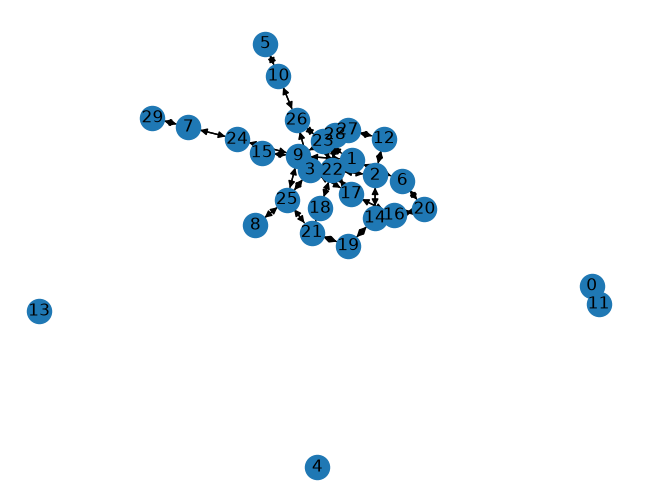

In [125]:
nx.draw(G_di, pos)
nx.draw_networkx_labels(G, pos, labels)

In [126]:
edge_list = list(G_di.edges())
edge_loc = {edge: index for index, edge in enumerate(edge_list)}

num_directed_edges = len(edge_list)

In [127]:
B = [
    [0 for _ in range(num_directed_edges)]
    for _ in range(num_directed_edges)
]

for row, (i, j) in enumerate(edge_list):
    for col, (k, l) in enumerate(edge_list):
        if l == i and k != j:
            B[row][col] = 1

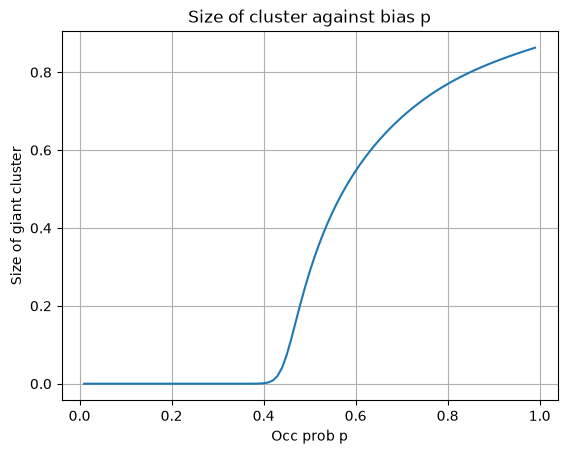

In [155]:
import numpy as np
B = jnp.array(B)

#instantiation of the message passing starts here
s_values = []
p_values = []
for p_choice in np.arange(1, 0, -0.01):
    p_values.append(p_choice)
    V = jnp.array([math.log(1-p_choice + p_choice*0.5) for i in range(G_di.number_of_edges())])
    #instantiate the mu_i
    pre_exp_mu_i = {node: 0.0 for node in G_di.nodes()}
    T = 50
    tol = 1e-9
    V_prev = V
    #iteration of message passing starts here
    for j in range(T):
        if j > 0 and jnp.max(jnp.abs(V - V_prev)) < tol:
            break
        V_prev = V
        V = jnp.log(1 - p_choice + p_choice * jnp.exp(jnp.matmul(B, V)))

    for i, e in enumerate(edge_list):
        pre_exp_mu_i[e[1]] += V[i]
    mu_i = {n: math.exp(pre_exp_mu_i[n]) for n in G_di.nodes()}
    s_values.append(1 - (1/N)*jnp.sum(jnp.array(list(mu_i.values()))))
plt.plot(p_values, s_values)
plt.xlabel("Occ prob p")
plt.ylabel("Size of giant cluster")
plt.title("Size of cluster against bias p")
plt.grid()

plt.show()